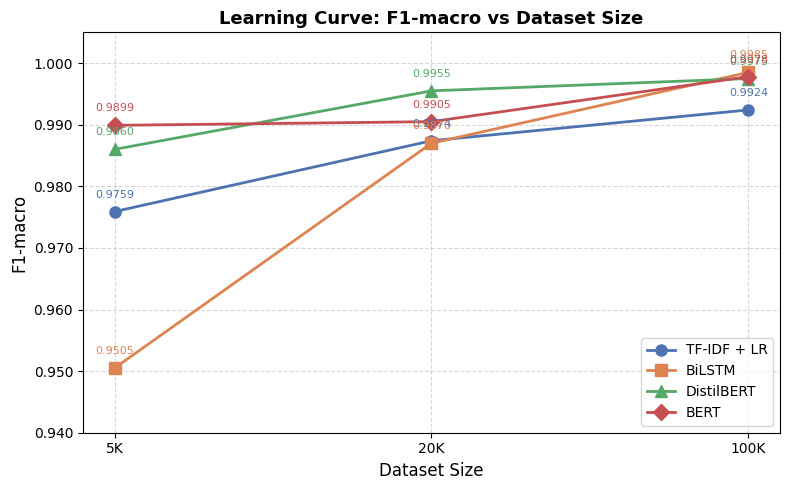

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

data_sizes = ['5K', '20K', '100K']

models = {
    'TF-IDF + LR':  [0.9759, 0.9874, 0.9924],
    'BiLSTM':       [0.9505, 0.9870, 0.9985],
    'DistilBERT':   [0.9860, 0.9955, 0.9975],
    'BERT':         [0.9899, 0.9905, 0.9978],
}

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
markers = ['o', 's', '^', 'D']

fig, ax = plt.subplots(figsize=(8, 5))

for (model_name, scores), color, marker in zip(models.items(), colors, markers):
    ax.plot(data_sizes, scores, marker=marker, color=color, linewidth=2,
            markersize=8, label=model_name)
    for i, (x, y) in enumerate(zip(data_sizes, scores)):
        ax.annotate(f'{y:.4f}', xy=(i, y),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=8, color=color)

ax.set_xlabel('Dataset Size', fontsize=12)
ax.set_ylabel('F1-macro', fontsize=12)
ax.set_title('Learning Curve: F1-macro vs Dataset Size', fontsize=13, fontweight='bold')
ax.set_ylim(0.94, 1.005)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

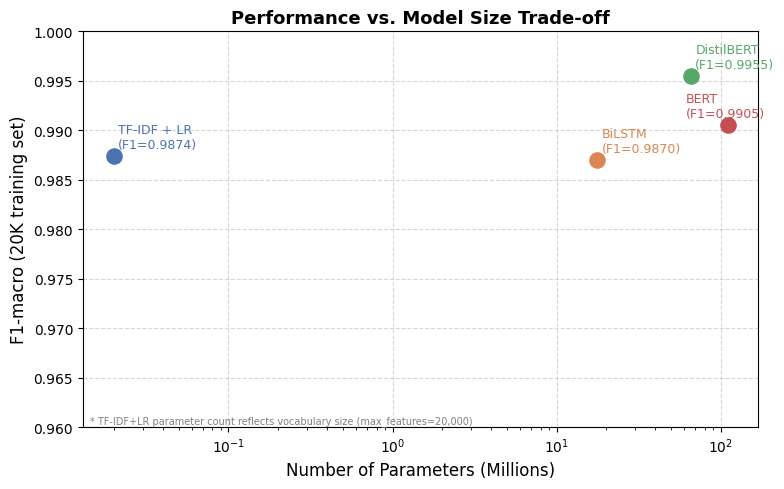

In [5]:
import matplotlib.pyplot as plt

models = ["TF-IDF + LR", "BiLSTM", "DistilBERT", "BERT"]
params = [0.02, 17.7, 66, 110]        # 单位：百万（M）
f1_scores = [0.9874, 0.9870, 0.9955, 0.9905]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(8, 5))

for i, (model, x, y, color) in enumerate(zip(models, params, f1_scores, colors)):
    ax.scatter(x, y, color=color, s=120, zorder=5)
    offset = (3, 6) if model != "BERT" else (-30, 6)
    ax.annotate(f"{model}\n(F1={y:.4f})",
                xy=(x, y),
                xytext=offset,
                textcoords="offset points",
                fontsize=9, color=color)

ax.set_xlabel("Number of Parameters (Millions)", fontsize=12)
ax.set_ylabel("F1-macro (20K training set)", fontsize=12)
ax.set_title("Performance vs. Model Size Trade-off", fontsize=13, fontweight="bold")
ax.set_xscale("log")
ax.set_ylim(0.96, 1.00)
ax.grid(True, linestyle="--", alpha=0.5)

ax.annotate("* TF-IDF+LR parameter count reflects vocabulary size (max_features=20,000)",
            xy=(0.01, 0.01), xycoords="axes fraction", fontsize=7, color="gray")

plt.tight_layout()
plt.savefig("tradeoff_scatter.png", dpi=150, bbox_inches="tight")
plt.show()